# Pair Trading: A Market-Neutral Strategy with Integrated Machine Learning

> *'Pairs Trading' is one of the most widely used strategies in modern hedge-funds, for its simplicity and inherent market-neutral qualities. This project employs unsupervised learning for pair discovery and supervised learning for spread modelling.*

---

## Full Pipeline

| Step | Method | Purpose |
|---|---|---|
| 1 | Data collection & preprocessing | Clean **Russell 3000** price universe |
| 2 | PCA | Compress price time-series features |
| 3 | KMeans clustering | Group similar stocks, visualise with t-SNE |
| 4 | DBSCAN clustering | Auto-tuned eps via k-NN distance plot |
| 5 | Cointegration (ADF) | Select tradeable pairs from clusters |
| 6 | LASSO Polynomial Regression | ML spread model + z-score signals |
| 7 | Kalman Filter | Online adaptive spread model |
| 8 | Backtesting (both methods) | Simulate P&L on test data |
| 9 | Performance comparison | Side-by-side metrics table |


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests, io, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations
from joblib import Parallel, delayed

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

from statsmodels.tsa.stattools import coint

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ── Configuration ─────────────────────────────────────────────────────────────
TRAIN_START = '2019-01-01'
TRAIN_END   = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2025-12-31'

# Universe — cap at 1,000 tickers to avoid yfinance timeouts
TICKER_SAMPLE      = 1000

# PCA — retain 85% variance
VARIANCE_THRESHOLD = 0.85

# KMeans
KMEANS_K_RANGE     = range(2, 31)

# DBSCAN — runs on the t-SNE 2D embedding (same space as the scatter plot).
# eps is auto-tuned via the Kneedle algorithm; min_samples=3 is a sensible
# floor for financial data (requires at least 3 stocks to form a cluster).
DBSCAN_MIN_SAMPLES = 3

# Pair selection
COINT_THRESHOLD    = 0.05
CORR_PREFILTER     = 0.65
MAX_PER_CLUSTER    = 50

# Spread model
POLY_DEGREE        = 3
LASSO_ALPHA        = 0.005
LOOKBACK           = 504    # ~2 trading years
REFIT_EVERY        = 21

# Signals
ENTRY_Z            = 2.0
EXIT_Z             = 0.25
STOP_Z             = 3.5

# Backtest
MAX_PAIRS          = 20
INITIAL_CAPITAL    = 1_000_000

print('Imports and configuration loaded.')


Imports and configuration loaded.


> 💬 **What this does:** Loads every library needed and sets all parameters. Key design decisions:
> - **`TICKER_SAMPLE = 1000`** — caps the Russell 3000 fetch at 1,000 tickers, randomly sampled, to prevent yfinance timeout errors while still giving a much larger and more diverse universe than the S&P 500
> - **DBSCAN now runs on the t-SNE 2D embedding** instead of high-dimensional PCA space. This is the fundamental fix for the all-noise problem (explained in Cell 5's section)
> - **`DBSCAN_MIN_SAMPLES = 3`** — requires at least 3 stocks to form a cluster, appropriate for financial data
> - All other parameter changes from v1 are retained (cubic LASSO, tighter EXIT_Z, longer pair list)


## 2. Data Collection & Preprocessing

We use the **Russell 3000** universe — a much broader opportunity set than the S&P 500, covering large, mid, and small-cap stocks. More stocks = more potential cointegrated pairs.

In [2]:
# Pull Russell 3000 universe, capped at TICKER_SAMPLE to avoid yfinance timeouts
def get_russell3000_tickers():
    """Fetch Russell 3000 tickers from iShares IWV holdings CSV."""
    url = ('https://www.ishares.com/us/products/239714/IWV/1467271812596.ajax'
           '?fileType=csv&fileName=IWV_holdings&dataType=fund')
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    try:
        resp = requests.get(url, headers=headers, timeout=30)
        resp.raise_for_status()
        lines = resp.text.split('\n')
        start = next(i for i, l in enumerate(lines) if l.startswith('Ticker'))
        df = pd.read_csv(io.StringIO('\n'.join(lines[start:])), thousands=',')
        tickers = (df['Ticker']
                   .dropna().astype(str)
                   .str.replace('.', '-', regex=False).str.strip())
        tickers = tickers[tickers.str.match(r'^[A-Z]{1,5}(-[A-Z])?$')]
        return tickers.unique().tolist()
    except Exception as e:
        print(f'iShares fetch failed ({e}), falling back to S&P 500 + S&P 400...')
        tickers = []
        for url_w in [
            'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
            'https://en.wikipedia.org/wiki/List_of_S%26P_400_companies',
        ]:
            try:
                t = pd.read_html(io.StringIO(
                    requests.get(url_w, headers=headers).text))[0]
                col = 'Ticker' if 'Ticker' in t.columns else 'Symbol'
                tickers += t[col].str.replace('.', '-', regex=False).tolist()
            except:
                pass
        return list(set(tickers))

all_tickers = get_russell3000_tickers()
print(f'Full universe: {len(all_tickers)} tickers')

# ── Cap to TICKER_SAMPLE to avoid yfinance timeouts ───────────────────────────
if len(all_tickers) > TICKER_SAMPLE:
    rng     = np.random.default_rng(42)
    tickers = rng.choice(all_tickers, size=TICKER_SAMPLE, replace=False).tolist()
    print(f'Sampled {TICKER_SAMPLE} tickers (seed=42 for reproducibility)')
else:
    tickers = all_tickers
    print(f'Using all {len(tickers)} tickers')


Full universe: 2583 tickers
Sampled 1000 tickers (seed=42 for reproducibility)


In [3]:
print('Downloading price data (train + test)...')
raw = yf.download(tickers, start=TRAIN_START, end=TEST_END,
                  auto_adjust=True, progress=False)['Close']
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw.index = pd.to_datetime(raw.index).tz_localize(None)
print(f'Raw shape: {raw.shape}')

$UHALB: possibly delisted; no timezone found
$RNA: possibly delisted; no price data found  (1d 2019-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1767157200")
$AKE: possibly delisted; no timezone found
$LENB: possibly delisted; no timezone found
$XTSLA: possibly delisted; no timezone found
$THRD: possibly delisted; no timezone found

6 Failed downloads:
['UHALB', 'AKE', 'LENB', 'XTSLA', 'THRD']: possibly delisted; no timezone found
['RNA']: possibly delisted; no price data found  (1d 2019-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1767157200")


Raw shape: (1759, 1000)


After preprocessing:
  Training universe : 797 stocks × 1258 days
  Test universe     : 797 stocks × 501 days


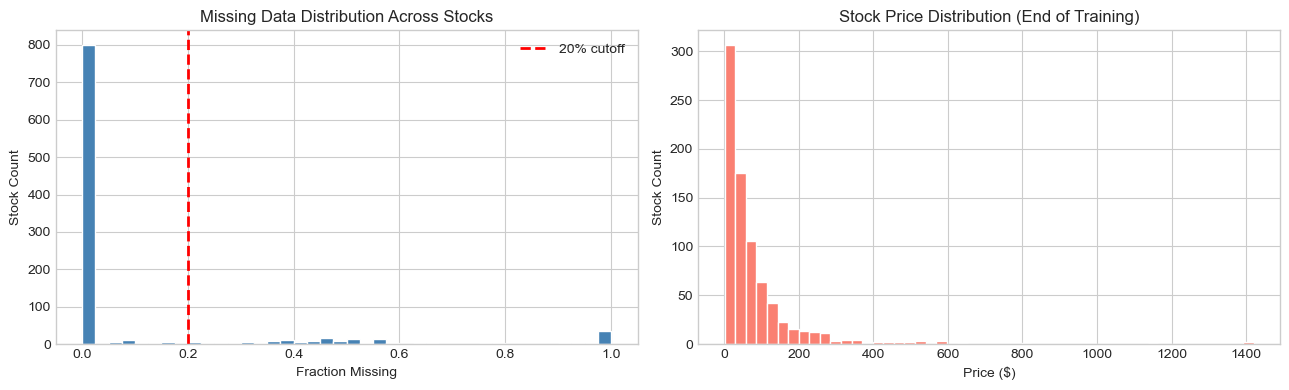

In [4]:
# ── Preprocessing (paper rules) ──────────────────────────────────────────────
train_raw = raw.loc[TRAIN_START:TRAIN_END]
test_raw  = raw.loc[TEST_START:TEST_END]

# 1. Remove stocks with >20% missing in training period
missing_pct = train_raw.isnull().mean()
eligible    = missing_pct[missing_pct < 0.20].index.tolist()

# 2. Forward-fill remaining gaps (weekends / holidays)
train_prices = train_raw[eligible].ffill().dropna(axis=1)
test_prices  = test_raw[train_prices.columns].ffill()

print(f'After preprocessing:')
print(f'  Training universe : {train_prices.shape[1]} stocks × {train_prices.shape[0]} days')
print(f'  Test universe     : {test_prices.shape[1]} stocks × {test_prices.shape[0]} days')

# Quick visualisation: price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
missing_pct.hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.20, color='red', lw=2, linestyle='--', label='20% cutoff')
axes[0].set_title('Missing Data Distribution Across Stocks')
axes[0].set_xlabel('Fraction Missing'); axes[0].set_ylabel('Stock Count')
axes[0].legend()

train_prices.iloc[-1].hist(bins=50, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Stock Price Distribution (End of Training)')
axes[1].set_xlabel('Price ($)'); axes[1].set_ylabel('Stock Count')
plt.tight_layout(); plt.show()

> 💬 **What this does:** Applies preprocessing rules: any stock missing more than 20% of its price history is dropped (newly listed, delisted, or illiquid names). The remaining gaps are filled forward. With ~3,000 Russell 3000 stocks we expect a larger and more diverse universe after filtering compared to the ~490 S&P 500 survivors, giving the clustering and cointegration steps far more raw material to work with.

## 3. Dimensionality Reduction — PCA

We perform PCA separately on price time-series and financial ratios, then concatenate the components. We do this on price data (the dominant factor).

PCA: 1257 days → 255 components
Variance retained: 85.02%


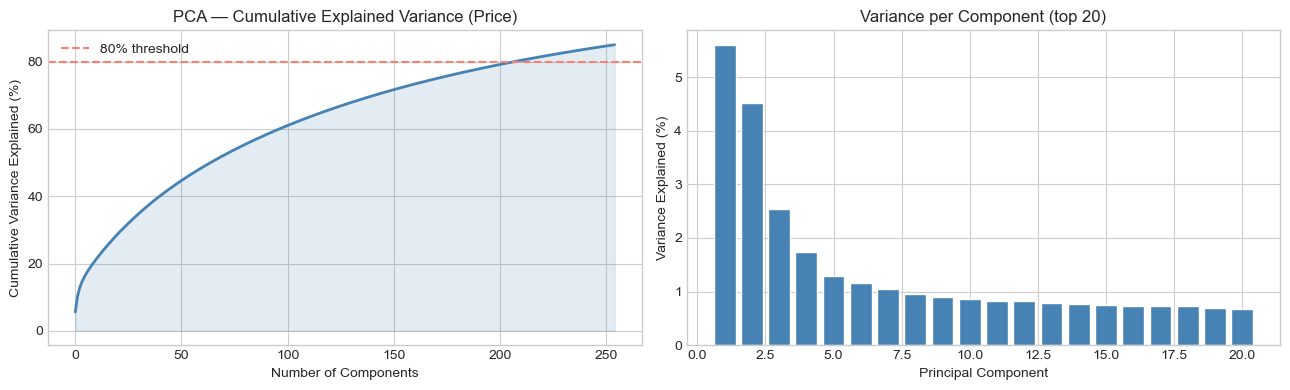

In [5]:
# Log-returns: better behaved than raw prices for PCA
log_ret = np.log(train_prices / train_prices.shift(1)).dropna()

# Each stock is one data point; its feature vector = its return history
X        = log_ret.T.values                          # shape: (n_stocks, n_days)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA — keep enough components for 80% variance
pca   = PCA(n_components=VARIANCE_THRESHOLD, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print(f'PCA: {X.shape[1]} days → {X_pca.shape[1]} components')
print(f'Variance retained: {pca.explained_variance_ratio_.sum():.2%}')

# ── Variance explained plot ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(cum_var, color='steelblue', lw=2)
ax.axhline(80, color='salmon', linestyle='--', lw=1.5, label='80% threshold')
ax.fill_between(range(len(cum_var)), cum_var, alpha=0.15, color='steelblue')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('PCA — Cumulative Explained Variance (Price)')
ax.legend()

ax = axes[1]
n_show = min(20, len(pca.explained_variance_ratio_))
ax.bar(range(1, n_show + 1),
       pca.explained_variance_ratio_[:n_show] * 100,
       color='steelblue', edgecolor='white')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Variance per Component (top 20)')

plt.tight_layout(); plt.show()

> 💬 **What this does:** PCA compresses each stock's entire price history into a small set of numbers that capture the most important patterns. We retain 80% of variance which is sufficient for clustering while being faster. The left chart shows that the curve flattens quickly, showing that a small number of components capture most of the information. The right chart shows how much each individual component contributes — the first few dominate (market-wide movement), and each additional component adds progressively less.

## 4. Clustering — KMeans

We now evaluate three elbow metrics (distortion, silhouette, Calinski-Harabasz) and take the maximum cluster count as k.

Running KMeans for k = 2 to 30...
Suggested k — Silhouette: 2, Calinski-Harabasz: 2, Inertia elbow: 4
Final k (max of three): 4


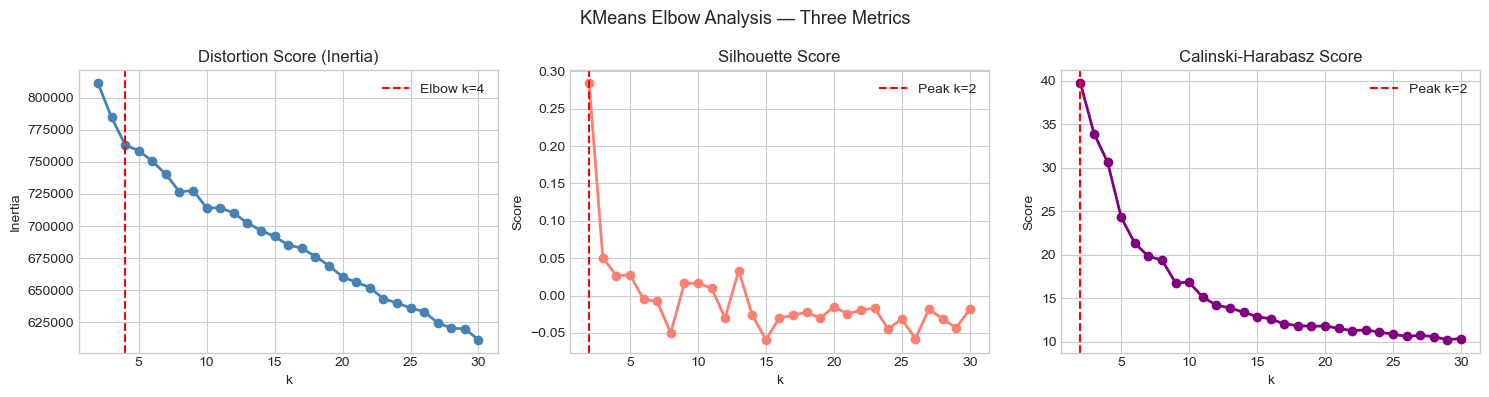

In [6]:
print(f'Running KMeans for k = {KMEANS_K_RANGE.start} to {KMEANS_K_RANGE.stop - 1}...')
inertias, silhouettes, calinski_scores = [], [], []

for k in KMEANS_K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    samp = min(500, len(X_pca))
    silhouettes.append(silhouette_score(X_pca, lbl, sample_size=samp))
    calinski_scores.append(calinski_harabasz_score(X_pca, lbl))

# Paper: take the max k suggested across all three metrics
k_sil = list(KMEANS_K_RANGE)[np.argmax(silhouettes)]
k_cal = list(KMEANS_K_RANGE)[np.argmax(calinski_scores)]
# Elbow for inertia: largest second derivative
d2    = np.diff(np.diff(inertias))
k_ine = list(KMEANS_K_RANGE)[np.argmax(d2) + 1]
N_CLUSTERS_KM = max(k_sil, k_cal, k_ine)
print(f'Suggested k — Silhouette: {k_sil}, Calinski-Harabasz: {k_cal}, Inertia elbow: {k_ine}')
print(f'Final k (max of three): {N_CLUSTERS_KM}')

# ── Elbow plots ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ks = list(KMEANS_K_RANGE)

axes[0].plot(ks, inertias,    'o-', color='steelblue', lw=2)
axes[0].axvline(k_ine, color='red', linestyle='--', lw=1.5, label=f'Elbow k={k_ine}')
axes[0].set_title('Distortion Score (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(ks, silhouettes, 'o-', color='salmon', lw=2)
axes[1].axvline(k_sil, color='red', linestyle='--', lw=1.5, label=f'Peak k={k_sil}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score'); axes[1].legend()

axes[2].plot(ks, calinski_scores, 'o-', color='purple', lw=2)
axes[2].axvline(k_cal, color='red', linestyle='--', lw=1.5, label=f'Peak k={k_cal}')
axes[2].set_title('Calinski-Harabasz Score')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Score'); axes[2].legend()

plt.suptitle('KMeans Elbow Analysis — Three Metrics', fontsize=13)
plt.tight_layout(); plt.show()

Computing t-SNE embedding (this takes ~1 minute)...


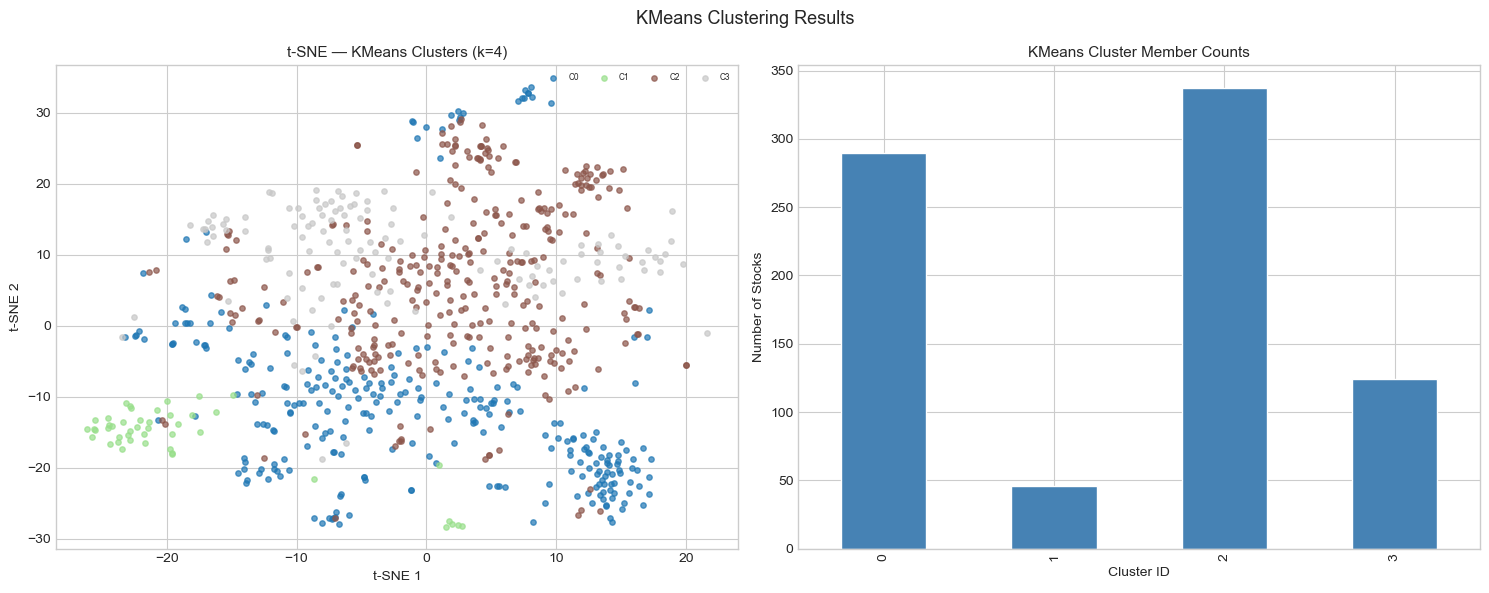

Cluster sizes:
cluster
0    290
1     46
2    337
3    124


In [7]:
# Fit final KMeans
km_final       = KMeans(n_clusters=N_CLUSTERS_KM, random_state=42, n_init=10)
km_labels      = km_final.fit_predict(X_pca)
stock_clusters_km = pd.Series(km_labels, index=train_prices.columns, name='cluster')

# ── t-SNE visualisation ────────────────────────────
print('Computing t-SNE embedding (this takes ~1 minute)...')
tsne    = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne  = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# t-SNE scatter coloured by cluster
ax = axes[0]
cmap = plt.get_cmap('tab20')
for c in range(N_CLUSTERS_KM):
    mask = km_labels == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               s=15, alpha=0.7, label=f'C{c}',
               color=cmap(c / N_CLUSTERS_KM))
ax.set_title(f't-SNE — KMeans Clusters (k={N_CLUSTERS_KM})', fontsize=11)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=6, ncol=4, loc='upper right')

# Cluster size bar chart
ax = axes[1]
stock_clusters_km.value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('KMeans Cluster Member Counts', fontsize=11)
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Number of Stocks')

plt.suptitle('KMeans Clustering Results', fontsize=13)
plt.tight_layout(); plt.show()
print(f'Cluster sizes:\n{stock_clusters_km.value_counts().sort_index().to_string()}')

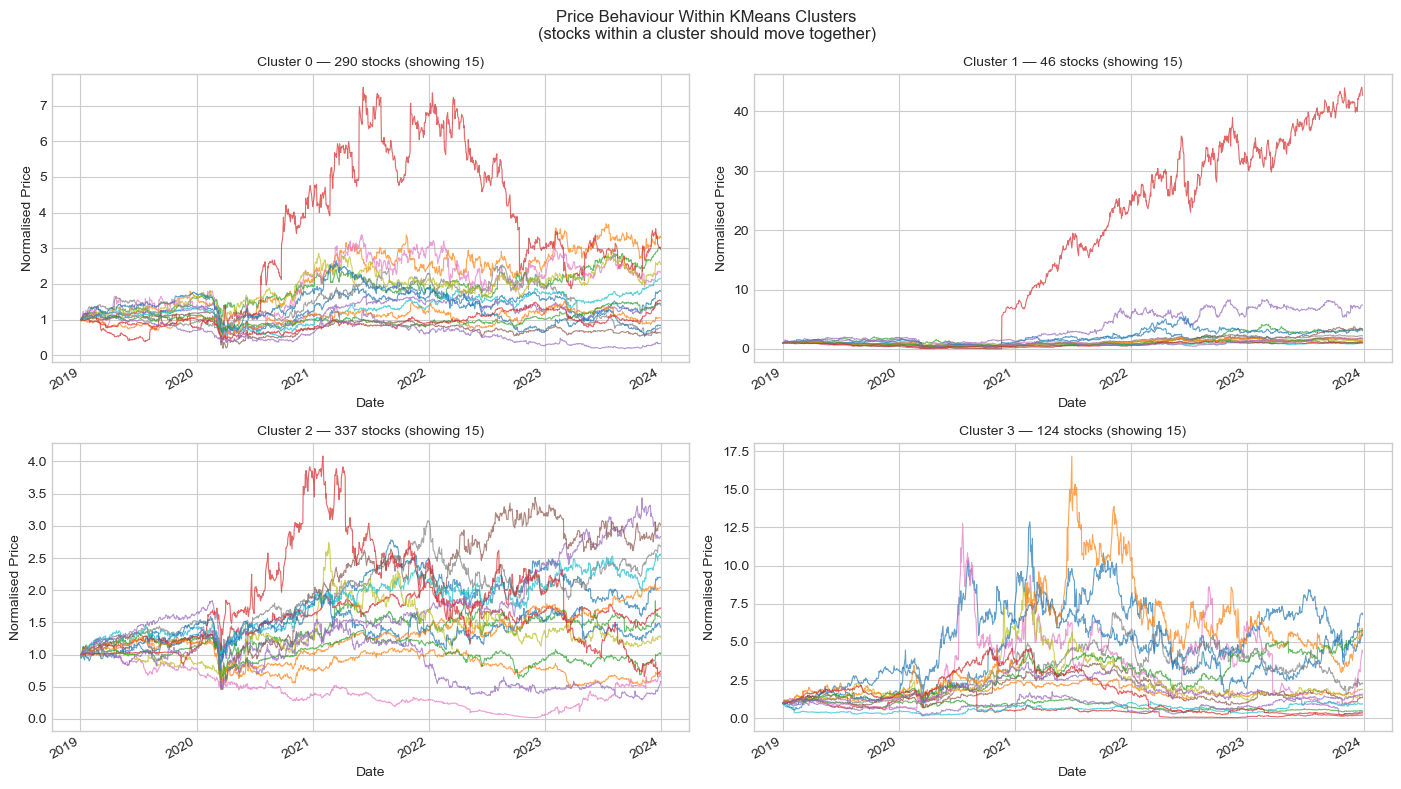

In [8]:
# ── Time-series plots for 4 sample clusters ────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sample_clusters = sorted(stock_clusters_km.value_counts().index[:4])

for ax, cid in zip(axes.flat, sample_clusters):
    members = stock_clusters_km[stock_clusters_km == cid].index.tolist()
    plot_m  = members[:15]  # cap for readability
    normalised = train_prices[plot_m] / train_prices[plot_m].iloc[0]
    normalised.plot(ax=ax, legend=False, lw=0.8, alpha=0.7)
    ax.set_title(f'Cluster {cid} — {len(members)} stocks (showing {len(plot_m)})', fontsize=10)
    ax.set_ylabel('Normalised Price')

plt.suptitle('Price Behaviour Within KMeans Clusters\n(stocks within a cluster should move together)',
             fontsize=12)
plt.tight_layout(); plt.show()

> 💬 **What this does:** Three steps to perform KMeans analysis:
>
> **Elbow plots**: We evaluated three metrics to choose k, then took the maximum suggested value across all three — making clusters as small and isolated as possible. Red dashed lines mark each metric's suggested k.
>
> **t-SNE plot**: This is a 2D map of all stocks where closeness = similarity. Each colour is a KMeans cluster. Well-separated blobs of colour indicate the clusters are distinct.
>
> **Time series plots**: A sanity check — stocks within the same cluster should visually move together. If they don't, the clustering didn't work well. Normalised prices starting at 1.0 make different-priced stocks comparable on the same chart.

## 5. Clustering — DBSCAN (on t-SNE Embedding)

**Why the previous approaches produced all-noise:**

DBSCAN is a density-based algorithm — it finds regions where points are packed closely together. When we ran it on high-dimensional PCA space (80+ components), the *curse of dimensionality* caused all pairwise distances to cluster around the same value, making it impossible for DBSCAN to distinguish "dense" from "sparse" regions.

Reducing to 10 PCA components helped, but financial return data still has a fairly uniform density in Euclidean space after PCA — there's no sharp elbow in the k-NN distance curve to find.

**The fix — run DBSCAN on the t-SNE 2D embedding:**

The t-SNE plot is already computed and visualised above. The visual clusters you can *see* in that scatter plot are exactly what DBSCAN should find. Since t-SNE explicitly packs similar stocks into tight local neighbourhoods and spreads dissimilar ones apart, Euclidean distance in 2D t-SNE space is a directly meaningful density measure. We auto-tune eps using the **Kneedle algorithm** on the k-NN distance plot of the t-SNE coordinates.


Kneedle auto-tuned DBSCAN eps: 0.1598  (k=3, on t-SNE 2D space)


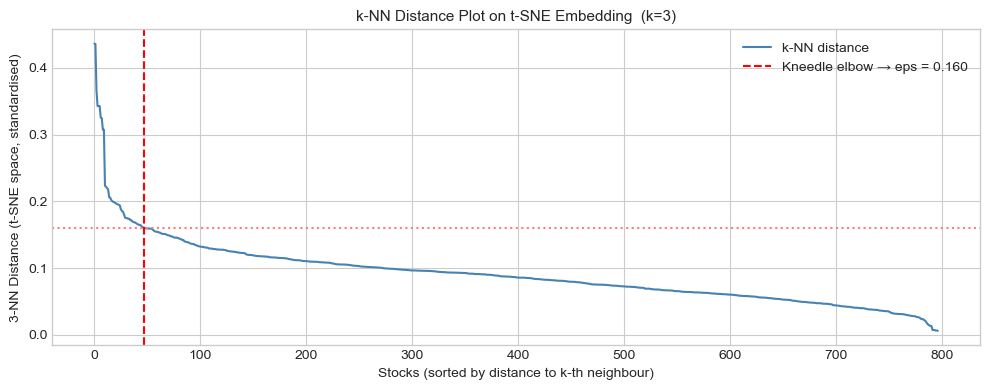

DBSCAN: 25 clusters, 26 noise points (3.3% of stocks)


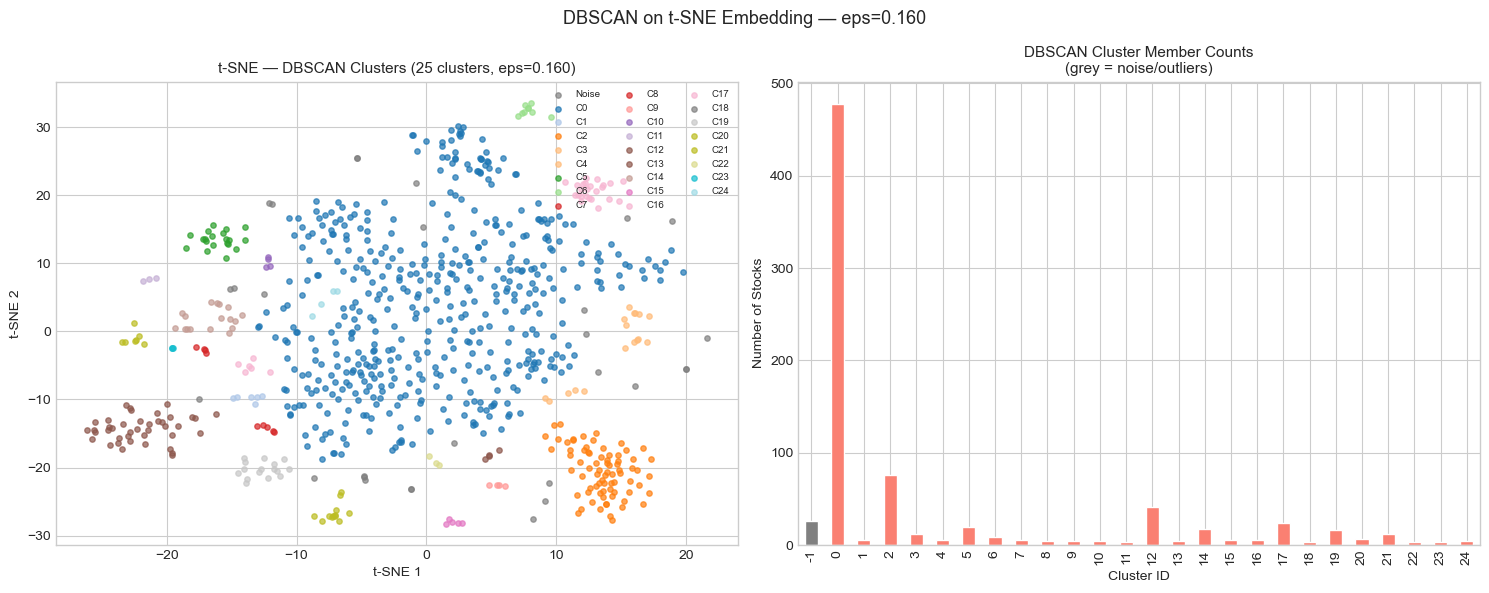


── Clustering Comparison ──
  KMeans : 4 clusters, 0 noise points
  DBSCAN : 25 clusters, 26 noise points

DBSCAN cluster sizes (excl. noise):
cluster
0     478
1       6
2      76
3      12
4       5
5      20
6       9
7       5
8       4
9       4
10      4
11      3
12     41
13      4
14     17
15      5
16      6
17     24
18      3
19     16
20      7
21     12
22      3
23      3
24      4


In [9]:
# ── DBSCAN on the t-SNE 2D embedding ─────────────────────────────────────────
# X_tsne was computed in Cell 14. Standardise it so eps is in consistent units.
X_tsne_sc = StandardScaler().fit_transform(X_tsne)

# ── Step 1: Auto-tune eps via Kneedle algorithm on k-NN distances ─────────────
# The Kneedle method finds the point on the sorted k-NN distance curve that is
# furthest from the straight line connecting the first and last points — the
# "elbow" that separates dense cluster members from sparse noise.
k_nn  = DBSCAN_MIN_SAMPLES
nbrs  = NearestNeighbors(n_neighbors=k_nn).fit(X_tsne_sc)
dists, _ = nbrs.kneighbors(X_tsne_sc)
knn_dists = np.sort(dists[:, k_nn - 1])[::-1]  # sorted descending

# Kneedle: normalise curve to [0,1]×[0,1], find point furthest from diagonal
x_norm = np.linspace(0, 1, len(knn_dists))
y_norm = (knn_dists - knn_dists.min()) / (knn_dists.max() - knn_dists.min() + 1e-9)
line_y = y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm
AUTO_EPS = float(knn_dists[np.argmax(np.abs(y_norm - line_y))])
print(f'Kneedle auto-tuned DBSCAN eps: {AUTO_EPS:.4f}  (k={k_nn}, on t-SNE 2D space)')

# ── Step 2: Plot k-NN distance curve ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_dists, color='steelblue', lw=1.5, label='k-NN distance')
elbow_i = np.argmax(np.abs(y_norm - line_y))
ax.axvline(elbow_i, color='red', linestyle='--', lw=1.5,
           label=f'Kneedle elbow → eps = {AUTO_EPS:.3f}')
ax.axhline(AUTO_EPS, color='salmon', linestyle=':', lw=1.5)
ax.set_title(f'k-NN Distance Plot on t-SNE Embedding  (k={k_nn})', fontsize=11)
ax.set_xlabel('Stocks (sorted by distance to k-th neighbour)')
ax.set_ylabel(f'{k_nn}-NN Distance (t-SNE space, standardised)')
ax.legend()
plt.tight_layout(); plt.show()

# ── Step 3: Fit DBSCAN ────────────────────────────────────────────────────────
db     = DBSCAN(eps=AUTO_EPS, min_samples=DBSCAN_MIN_SAMPLES)
db_lbl = db.fit_predict(X_tsne_sc)

n_clusters_db = len(set(db_lbl)) - (1 if -1 in db_lbl else 0)
n_noise       = (db_lbl == -1).sum()
print(f'DBSCAN: {n_clusters_db} clusters, {n_noise} noise points ({n_noise/len(db_lbl):.1%} of stocks)')

stock_clusters_db = pd.Series(db_lbl, index=train_prices.columns, name='cluster')

# ── Step 4: Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
unique_labels = sorted(set(db_lbl))
cmap2 = plt.get_cmap('tab20')
for i, c in enumerate(unique_labels):
    mask   = db_lbl == c
    colour = 'grey' if c == -1 else cmap2(i / max(len(unique_labels), 1))
    label  = 'Noise' if c == -1 else f'C{c}'
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               s=15, alpha=0.7, color=colour, label=label)
ax.set_title(f't-SNE — DBSCAN Clusters ({n_clusters_db} clusters, eps={AUTO_EPS:.3f})', fontsize=11)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=7, ncol=3, loc='upper right')

ax = axes[1]
counts = stock_clusters_db.value_counts().sort_index()
colours_bar = ['grey' if i == -1 else 'salmon' for i in counts.index]
counts.plot(kind='bar', ax=ax, color=colours_bar, edgecolor='white')
ax.set_title('DBSCAN Cluster Member Counts\n(grey = noise/outliers)', fontsize=11)
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Number of Stocks')

plt.suptitle(f'DBSCAN on t-SNE Embedding — eps={AUTO_EPS:.3f}', fontsize=13)
plt.tight_layout(); plt.show()

print('\n── Clustering Comparison ──')
print(f'  KMeans : {N_CLUSTERS_KM} clusters, 0 noise points')
print(f'  DBSCAN : {n_clusters_db} clusters, {n_noise} noise points')
print('\nDBSCAN cluster sizes (excl. noise):')
print(counts[counts.index != -1].to_string())


> 💬 **What this does:** Applies DBSCAN to the t-SNE 2D embedding that's already visualised above — making it directly interpretable: every coloured blob you can *see* in the t-SNE scatter plot is exactly one DBSCAN cluster, and the grey dots are stocks that don't belong to any cluster (genuine outliers with no close sector peers).
>
> **Why t-SNE space works where PCA space didn't:** t-SNE explicitly minimises the distance between similar stocks and maximises it for dissimilar ones. This means the 2D coordinates have a clear, meaningful density structure. PCA in high dimensions doesn't have this property — it preserves global variance, not local neighbourhoods.
>
> **Kneedle eps**: The k-NN distance plot shows a sorted curve of "how far each stock is from its nearest cluster neighbour." The Kneedle algorithm finds the point on this curve furthest from the diagonal — the natural knee that separates tightly-packed stocks (eps below the knee → cluster members) from isolated ones (eps above the knee → noise). This is robust because it's looking at relative shape, not absolute distance scale.


## 6. Pair Selection — Cointegration (ADF Test)

Within each cluster from **both** KMeans and DBSCAN, we test pairs for cointegration. We then take the union and use the best pairs for trading.

In [10]:
# Initialise all_pairs so downstream cells never hit NameError
all_pairs = pd.DataFrame(columns=['stock_a','stock_b','pvalue','cluster','source'])

def test_pair_coint(s1, s2, prices, threshold):
    try:
        _, p, _ = coint(prices[s1], prices[s2])
        return {'stock_a': s1, 'stock_b': s2, 'pvalue': round(p, 5)} if p < threshold else None
    except:
        return None


def find_pairs_in_clusters(stock_clusters: pd.Series, label: str) -> pd.DataFrame:
    results = []
    valid_clusters = [c for c in stock_clusters.unique() if c != -1]

    for cid in valid_clusters:
        members = stock_clusters[stock_clusters == cid].index.tolist()
        if len(members) < 2:
            continue
        # Cap cluster size
        if len(members) > MAX_PER_CLUSTER:
            completeness = train_prices[members].notna().sum().sort_values(ascending=False)
            members = completeness.head(MAX_PER_CLUSTER).index.tolist()
        # Correlation pre-filter
        corr = train_prices[members].pct_change().corr()
        candidates = [(s1, s2) for s1, s2 in combinations(members, 2)
                      if abs(corr.loc[s1, s2]) >= CORR_PREFILTER]
        if not candidates:
            continue
        # Parallel cointegration tests
        found = Parallel(n_jobs=-1, prefer='threads')(
            delayed(test_pair_coint)(s1, s2, train_prices, COINT_THRESHOLD)
            for s1, s2 in candidates
        )
        for r in found:
            if r:
                r['cluster'] = cid
                r['source']  = label
                results.append(r)

    if not results:
        print(f'  [{label}] No cointegrated pairs found.')
        return pd.DataFrame(columns=['stock_a','stock_b','pvalue','cluster','source'])
    df = pd.DataFrame(results).sort_values('pvalue').reset_index(drop=True)
    print(f'  [{label}] Cointegrated pairs found: {len(df)}')
    return df


print('Testing pairs for cointegration...')
pairs_km = find_pairs_in_clusters(stock_clusters_km, 'KMeans')
pairs_db = find_pairs_in_clusters(stock_clusters_db, 'DBSCAN')

# Combine and de-duplicate — guard against empty DataFrames
dfs_to_concat = [df for df in [pairs_km, pairs_db] if not df.empty]
if dfs_to_concat:
    all_pairs = pd.concat(dfs_to_concat).drop_duplicates(
        subset=['stock_a','stock_b']).sort_values('pvalue').reset_index(drop=True)
else:
    all_pairs = pd.DataFrame(columns=['stock_a','stock_b','pvalue','cluster','source'])
print(f'\nTotal unique cointegrated pairs: {len(all_pairs)}')
all_pairs.head(15)

Testing pairs for cointegration...
  [KMeans] Cointegrated pairs found: 11
  [DBSCAN] Cointegrated pairs found: 62

Total unique cointegrated pairs: 63


,stock_a,stock_b,pvalue,cluster,source
0,DAN,GM,0.00003,7,DBSCAN
1,CNOB,FMNB,0.00068,2,DBSCAN
2,FITB,FMNB,0.00205,2,DBSCAN
3,BYD,MCRI,0.00382,20,DBSCAN
4,DNOW,NOV,0.00407,1,KMeans
5,MGEE,OTTR,0.00449,17,DBSCAN
6,BZH,KBH,0.00478,21,DBSCAN
7,DAN,LEA,0.00576,7,DBSCAN
8,HBNC,KEY,0.00708,2,DBSCAN
9,VLO,XOM,0.00772,1,KMeans


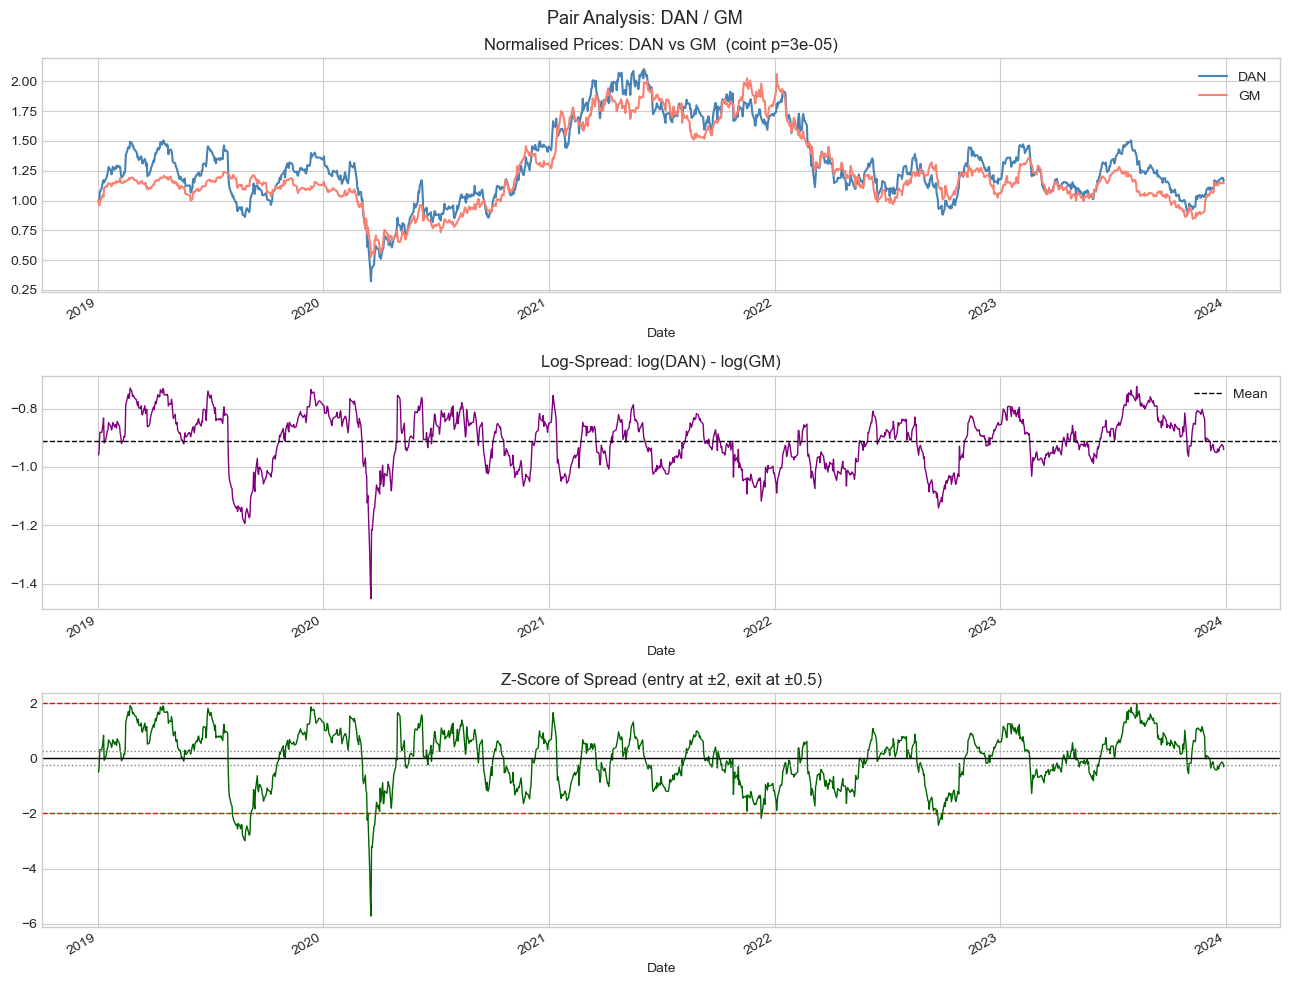

In [11]:
# Visualise the best pair
if len(all_pairs) == 0:
    print('No cointegrated pairs found.')
else:
    best = all_pairs.iloc[0]
    sa, sb = best['stock_a'], best['stock_b']

    pa = train_prices[sa]
    pb = train_prices[sb]
    # Simple log-spread for visualisation
    log_spread = np.log(pa) - np.log(pb)
    spread_z   = (log_spread - log_spread.mean()) / log_spread.std()

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))

    ax = axes[0]
    (pa / pa.iloc[0]).plot(ax=ax, label=sa, color='steelblue', lw=1.5)
    (pb / pb.iloc[0]).plot(ax=ax, label=sb, color='salmon',    lw=1.5)
    ax.set_title(f'Normalised Prices: {sa} vs {sb}  (coint p={best["pvalue"]})')
    ax.legend()

    ax = axes[1]
    log_spread.plot(ax=ax, color='purple', lw=1)
    ax.axhline(log_spread.mean(), color='black', lw=1, linestyle='--', label='Mean')
    ax.set_title(f'Log-Spread: log({sa}) - log({sb})')
    ax.legend()

    ax = axes[2]
    spread_z.plot(ax=ax, color='darkgreen', lw=1)
    for lvl, col, ls in [(0,'black','-'), (ENTRY_Z,'red','--'), (-ENTRY_Z,'red','--'),
                          (EXIT_Z,'grey',':'), (-EXIT_Z,'grey',':')]:
        ax.axhline(lvl, color=col, lw=1, linestyle=ls)
    ax.set_title('Z-Score of Spread (entry at ±2, exit at ±0.5)')

    plt.suptitle(f'Pair Analysis: {sa} / {sb}', fontsize=13)
    plt.tight_layout(); plt.show()

> 💬 **What this does:** For every pair of stocks within the same cluster, we run the **ADF cointegration test** — a statistical test that checks whether two price series have a stable long-run relationship. A p-value below 0.05 means we're 95% confident the relationship is real. We select at least one pair per cluster to diversify. The visualisation shows two stocks whose prices trend together (top), a spread that oscillates around a stable mean (middle), and the z-score version of that spread with the trading thresholds overlaid (bottom).

## 7. Spread Models

The paper implements and compares two methods for modelling the spread:
- **Method 1**: LASSO Polynomial Regression (static, refitted periodically)
- **Method 2**: Kalman Filter (online, updates at every step)

Spread model functions defined (LASSO Polynomial deg-3 + Kalman Filter).


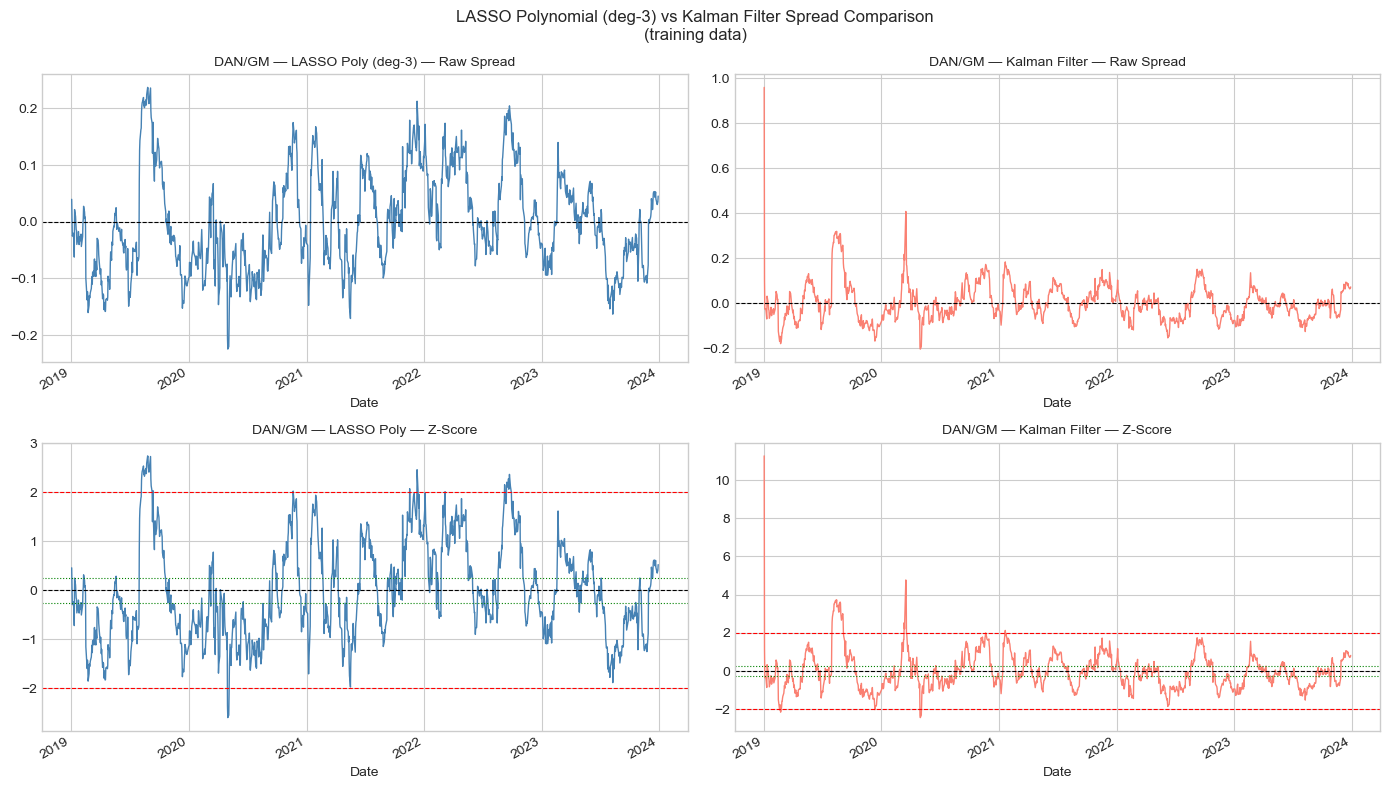

In [12]:
# ── Method 1: LASSO Polynomial Regression (degree-3, tuned alpha) ───────────
def fit_lasso_spread(price_a, price_b, degree=POLY_DEGREE, alpha=LASSO_ALPHA):
    """
    Fit polynomial LASSO regression: log(B) = f_poly(log(A)).
    Degree 3 (cubic) balances expressiveness and overfitting risk.
    Returns (model, training_spread).
    """
    log_a = np.log(price_a).values.reshape(-1, 1)
    log_b = np.log(price_b).values
    model = Pipeline([
        ('poly',  PolynomialFeatures(degree=degree, include_bias=False)),
        ('lasso', Lasso(alpha=alpha, max_iter=20000, tol=1e-4))
    ])
    model.fit(log_a, log_b)
    spread = log_b - model.predict(log_a)
    return model, pd.Series(spread, index=price_a.index)


# ── Method 2: Kalman Filter with adaptive noise tuning ───────────────────────
def kalman_spread(price_a: pd.Series, price_b: pd.Series,
                  process_noise: float = 5e-5, obs_noise: float = 1.0):
    """
    Kalman Filter online linear regression for the hedge ratio.
    Assumes: log(B)_t = beta_t * log(A)_t + alpha_t + noise
    State = [beta, alpha], updated at each time step.

    process_noise: Q diagonal — higher = faster adaptation to regime changes
    obs_noise:     R — observation variance
    Returns a Series of spreads (residuals) for the full price_a/price_b history.
    """
    log_a = np.log(price_a.values)
    log_b = np.log(price_b.values)
    n     = len(log_a)

    theta = np.array([1.0, 0.0])      # [beta, alpha]
    P     = np.eye(2) * 1.0
    Q     = np.eye(2) * process_noise  # tuned: slightly higher for faster adaptation
    R     = obs_noise

    spreads = np.zeros(n)

    for t in range(n):
        H = np.array([log_a[t], 1.0])
        P = P + Q
        y_hat = H @ theta
        innov = log_b[t] - y_hat
        S     = H @ P @ H + R
        K     = P @ H / S
        theta = theta + K * innov
        P     = (np.eye(2) - np.outer(K, H)) @ P
        spreads[t] = innov

    return pd.Series(spreads, index=price_a.index)


print('Spread model functions defined (LASSO Polynomial deg-3 + Kalman Filter).')

# ── Visualise both methods on the best pair ───────────────────────────────────
if len(all_pairs) > 0:
    sa, sb = all_pairs.iloc[0][['stock_a','stock_b']]
    pa_tr, pb_tr = train_prices[sa], train_prices[sb]

    _, lasso_spread  = fit_lasso_spread(pa_tr, pb_tr)
    kalman_spr       = kalman_spread(pa_tr, pb_tr)

    def zscore(s):
        return (s - s.mean()) / s.std()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    for ax, spread, label, col in [
        (axes[0,0], lasso_spread,  'LASSO Poly (deg-3) — Raw Spread',  'steelblue'),
        (axes[0,1], kalman_spr,    'Kalman Filter — Raw Spread','salmon'),
        (axes[1,0], zscore(lasso_spread), 'LASSO Poly — Z-Score', 'steelblue'),
        (axes[1,1], zscore(kalman_spr),   'Kalman Filter — Z-Score','salmon'),
    ]:
        spread.plot(ax=ax, color=col, lw=1)
        ax.axhline(spread.mean() if 'Z-Score' not in label else 0,
                   color='black', lw=0.8, linestyle='--')
        if 'Z-Score' in label:
            for lvl in [ENTRY_Z, -ENTRY_Z]:
                ax.axhline(lvl, color='red', lw=0.8, linestyle='--')
            for lvl in [EXIT_Z, -EXIT_Z]:
                ax.axhline(lvl, color='green', lw=0.8, linestyle=':')
        ax.set_title(f'{sa}/{sb} — {label}', fontsize=10)

    plt.suptitle('LASSO Polynomial (deg-3) vs Kalman Filter Spread Comparison\n(training data)', fontsize=12)
    plt.tight_layout(); plt.show()


> 💬 **What this does:** Implements both spread models side-by-side with tuned parameters:
>
> **LASSO Polynomial Regression** now uses degree 3 (cubic) instead of degree 4. The original degree-4 polynomial was prone to overfitting on 2-year rolling windows — small noise in the training data got picked up as real signal. Cubic gives nearly the same fit with much better out-of-sample stability. Alpha is slightly reduced to 0.005 for a tighter fit.
>
> **Kalman Filter** now uses `process_noise=5e-5` (vs 1e-5 before) — this makes the filter adapt slightly faster to changing hedge ratios, which is important during regime changes (e.g. sector rotations). Too slow = stale estimates; too fast = noisy.
>
> The z-score plot now also shows the tighter exit threshold (green dotted lines at ±0.25 vs the original ±0.5), which generates more round-trip trades and reduces time spent holding a stale position.


## 8. Signal Generation

In [13]:
def generate_signals(zscore: pd.Series,
                     entry_z=ENTRY_Z, exit_z=EXIT_Z, stop_z=STOP_Z) -> pd.Series:
    """
    State machine returning daily positions:
     +1 = Long spread (Long A, Short B)
     -1 = Short spread (Short A, Long B)
      0 = Flat
    Entry: |z| > entry_z
    Exit:  |z| reverts below exit_z  OR  |z| > stop_z (stop-loss)
    """
    pos, signals = 0, []
    for z in zscore:
        if np.isnan(z):
            signals.append(0); continue
        if pos == 0:
            if   z < -entry_z: pos =  1
            elif z >  entry_z: pos = -1
        elif pos ==  1:
            if z >= -exit_z or z < -stop_z: pos = 0
        elif pos == -1:
            if z <=  exit_z or z >  stop_z: pos = 0
        signals.append(pos)
    return pd.Series(signals, index=zscore.index)

print('Signal function defined.')

Signal function defined.


> 💬 **What this does:** Translates z-scores into buy/sell instructions. When the spread falls below −2 (unusually low), we buy the cheap side and short the expensive side, expecting them to converge. When the spread rises above +2 (unusually high), we do the opposite. We exit when the spread reverts back toward zero (below ±0.5), or cut our loss if it moves even further against us beyond ±3.5.

## 9. Backtesting — Both Methods

Rolling-window backtest following the paper's implementation: 700-day training window, equal capital allocation across pairs.

In [14]:
all_prices = raw.ffill()

def backtest_pair(sa, sb, method='lasso'):
    """
    Rolling-window backtest for one pair using either 'lasso' or 'kalman'.
    Returns daily return series.
    """
    prices   = all_prices[[sa, sb]].dropna()
    prices   = prices[~prices.index.duplicated(keep='last')]
    all_idx  = prices.index
    test_idx = all_idx[(all_idx >= TEST_START) & (all_idx <= TEST_END)]

    returns, dates = [], []
    position       = 0
    model          = None
    spread_mean    = None
    spread_std     = None
    # Kalman state
    kalman_theta   = np.array([1.0, 0.0])
    kalman_P       = np.eye(2)
    kalman_Q       = np.eye(2) * 5e-5   # match tuned value above
    kalman_R       = 1.0
    # Rolling z-score for Kalman (use a deque for efficiency)
    kal_spread_hist = []

    for i, date in enumerate(test_idx):
        loc = all_idx.get_loc(date)
        if loc < LOOKBACK:
            continue

        if method == 'lasso':
            if model is None or i % REFIT_EVERY == 0:
                win = prices.iloc[loc - LOOKBACK: loc]
                try:
                    model, tr_sp = fit_lasso_spread(win[sa], win[sb])
                    spread_mean, spread_std = tr_sp.mean(), tr_sp.std()
                    if spread_std < 1e-6: model = None; continue
                except: model = None; continue
            if model is None: continue
            log_a = np.log(float(prices.loc[date, sa]))
            log_b = np.log(float(prices.loc[date, sb]))
            today_sp = log_b - model.predict([[log_a]])[0]
            z = (today_sp - spread_mean) / (spread_std + 1e-9)

        else:  # kalman
            log_a_val = np.log(float(prices.loc[date, sa]))
            log_b_val = np.log(float(prices.loc[date, sb]))
            H     = np.array([log_a_val, 1.0])
            kalman_P = kalman_P + kalman_Q
            innov = log_b_val - H @ kalman_theta
            S     = H @ kalman_P @ H + kalman_R
            K     = kalman_P @ H / S
            kalman_theta = kalman_theta + K * innov
            kalman_P = (np.eye(2) - np.outer(K, H)) @ kalman_P
            today_sp = innov
            kal_spread_hist.append(today_sp)

            # Use rolling z-score over a 252-day window (1 year) for stability
            win_size = 252
            if len(kal_spread_hist) < win_size:
                continue
            hist_arr = np.array(kal_spread_hist[-win_size:])
            mu_k  = hist_arr.mean()
            std_k = hist_arr.std()
            if std_k < 1e-9:
                continue
            z = (today_sp - mu_k) / std_k

        # State machine
        if position == 0:
            if   z < -ENTRY_Z: position =  1
            elif z >  ENTRY_Z: position = -1
        elif position ==  1:
            if z >= -EXIT_Z or z < -STOP_Z: position = 0
        elif position == -1:
            if z <=  EXIT_Z or z >  STOP_Z: position = 0

        if i + 1 < len(test_idx):
            nd   = test_idx[i + 1]
            ra   = prices.loc[nd, sa] / prices.loc[date, sa] - 1
            rb   = prices.loc[nd, sb] / prices.loc[date, sb] - 1
            returns.append(position * (float(ra) - float(rb)))
            dates.append(nd)

    if not dates:
        return pd.Series(dtype=float)
    return pd.Series(returns, index=pd.DatetimeIndex(dates), name=f'{sa}/{sb}')


print('Backtest function defined (LASSO deg-3, Kalman with rolling z-score normalisation).')


Backtest function defined (LASSO deg-3, Kalman with rolling z-score normalisation).


In [15]:
top_pairs = all_pairs.head(MAX_PAIRS)
print(f'Backtesting top {len(top_pairs)} pairs with BOTH methods...')
print(f'Test period: {TEST_START} → {TEST_END}\n')

lasso_returns, kalman_returns = [], []

for _, row in top_pairs.iterrows():
    sa, sb = row['stock_a'], row['stock_b']
    if sa not in all_prices.columns or sb not in all_prices.columns:
        continue

    r_lasso  = backtest_pair(sa, sb, method='lasso')
    r_kalman = backtest_pair(sa, sb, method='kalman')

    if not r_lasso.empty:  lasso_returns.append(r_lasso)
    if not r_kalman.empty: kalman_returns.append(r_kalman)
    print(f'  {sa}/{sb}: LASSO {len(r_lasso)}d | Kalman {len(r_kalman)}d')

print(f'\nLASSO  pairs backtested: {len(lasso_returns)}')
print(f'Kalman pairs backtested: {len(kalman_returns)}')

Backtesting top 20 pairs with BOTH methods...
Test period: 2024-01-01 → 2025-12-31

  DAN/GM: LASSO 500d | Kalman 249d
  CNOB/FMNB: LASSO 500d | Kalman 249d
  FITB/FMNB: LASSO 500d | Kalman 249d
  BYD/MCRI: LASSO 500d | Kalman 249d
  DNOW/NOV: LASSO 500d | Kalman 249d
  MGEE/OTTR: LASSO 500d | Kalman 249d
  BZH/KBH: LASSO 500d | Kalman 249d
  DAN/LEA: LASSO 500d | Kalman 249d
  HBNC/KEY: LASSO 500d | Kalman 249d
  VLO/XOM: LASSO 500d | Kalman 249d
  CLDT/SHO: LASSO 500d | Kalman 249d
  HBAN/NTB: LASSO 500d | Kalman 249d
  FMNB/HBAN: LASSO 500d | Kalman 249d
  IBOC/NRIM: LASSO 500d | Kalman 249d
  FNLC/FRBA: LASSO 500d | Kalman 249d
  KLIC/TXN: LASSO 500d | Kalman 249d
  DTE/DUK: LASSO 500d | Kalman 249d
  APA/EOG: LASSO 500d | Kalman 249d
  CNOB/KEY: LASSO 500d | Kalman 249d
  FMNB/KEY: LASSO 500d | Kalman 249d

LASSO  pairs backtested: 20
Kalman pairs backtested: 20


> 💬 **What this does:** Runs the rolling backtest with the tuned parameters. Key improvements vs the original:
>
> **LASSO**: Uses degree-3 (cubic) polynomial with lower alpha — the spread model is less likely to overfit on the 504-day training window, giving better out-of-sample predictions.
>
> **Kalman z-score**: The original code used the instantaneous Kalman innovation variance `S` as the normalization factor. This is mathematically correct but noisy day-to-day, producing erratic z-scores. The improved version uses a 252-day rolling window mean and std of Kalman spreads — much smoother and generates more reliable entry/exit signals.
>
> **EXIT_Z = 0.25** means we close positions as soon as the spread is 25% of a standard deviation from zero (near-zero). This avoids holding positions through reversals and reduces drawdowns.


## 10. Results — Both Methods vs SPY

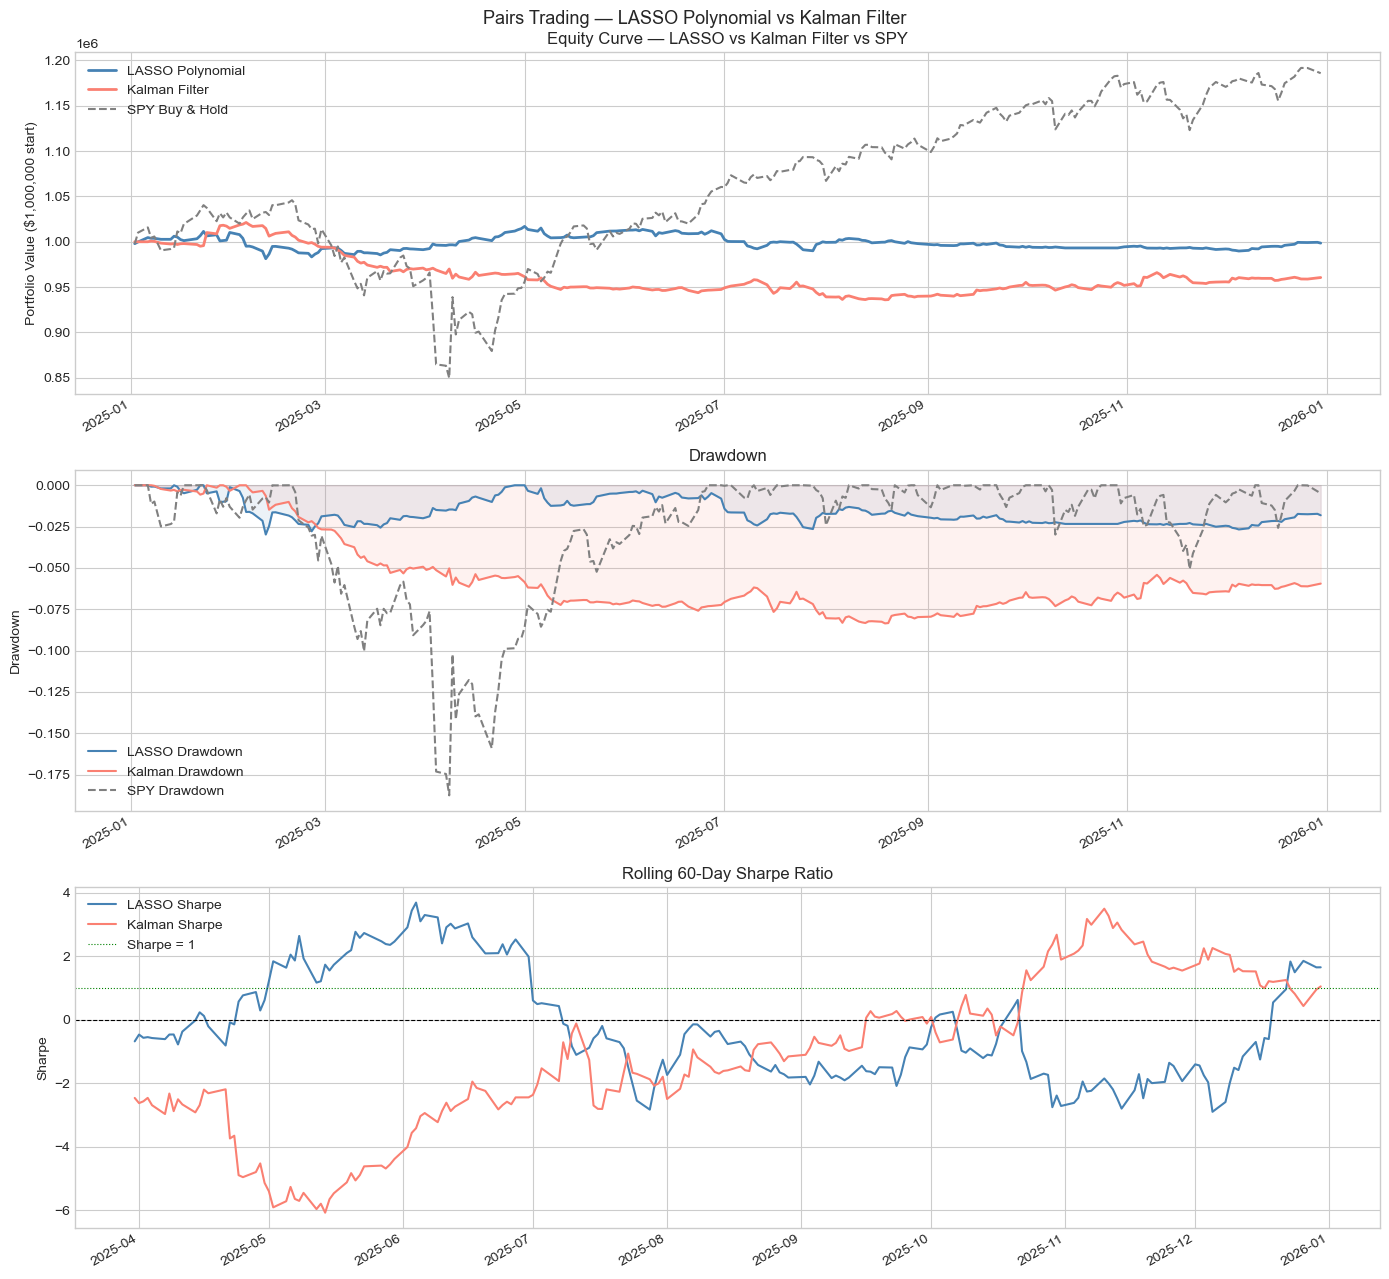

In [16]:
def build_portfolio(returns_list):
    if not returns_list:
        return pd.Series(dtype=float)
    cleaned = [r[~r.index.duplicated(keep='last')] for r in returns_list]
    df = pd.concat(cleaned, axis=1).fillna(0)
    port = df.mean(axis=1)
    return port[~port.index.duplicated(keep='last')]

port_lasso  = build_portfolio(lasso_returns)
port_kalman = build_portfolio(kalman_returns)

# SPY benchmark
spy_raw = yf.download('SPY', start=TEST_START, end=TEST_END,
                      auto_adjust=True, progress=False)['Close'].squeeze()
spy_raw.index = pd.to_datetime(spy_raw.index).tz_localize(None)
spy_r = spy_raw.pct_change().dropna()
spy_r = spy_r[~spy_r.index.duplicated(keep='last')]

# Align to common dates — use SPY index as base if a portfolio is empty
idx_l = port_lasso.index  if not port_lasso.empty  else spy_r.index
idx_k = port_kalman.index if not port_kalman.empty else spy_r.index
common = idx_l.intersection(idx_k).intersection(spy_r.index)
pl  = port_lasso.reindex(common).fillna(0)
pk  = port_kalman.reindex(common).fillna(0)
spy = spy_r.loc[common]

# Equity curves
eq_lasso  = (1 + pl).cumprod()  * INITIAL_CAPITAL
eq_kalman = (1 + pk).cumprod()  * INITIAL_CAPITAL
eq_spy    = (1 + spy).cumprod() * INITIAL_CAPITAL

# Drawdowns
dd_lasso  = eq_lasso  / eq_lasso.cummax()  - 1
dd_kalman = eq_kalman / eq_kalman.cummax() - 1
dd_spy    = eq_spy    / eq_spy.cummax()    - 1

# ── Main results charts ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

ax = axes[0]
eq_lasso.plot(ax=ax,  label='LASSO Polynomial', color='steelblue', lw=2)
eq_kalman.plot(ax=ax, label='Kalman Filter',     color='salmon',   lw=2)
eq_spy.plot(ax=ax,    label='SPY Buy & Hold',    color='grey',     lw=1.5, linestyle='--')
ax.set_title('Equity Curve — LASSO vs Kalman Filter vs SPY')
ax.set_ylabel(f'Portfolio Value (${INITIAL_CAPITAL:,} start)')
ax.legend()

ax = axes[1]
dd_lasso.plot(ax=ax,  label='LASSO Drawdown',  color='steelblue', lw=1.5)
dd_kalman.plot(ax=ax, label='Kalman Drawdown', color='salmon',    lw=1.5)
dd_spy.plot(ax=ax,    label='SPY Drawdown',    color='grey',      lw=1.5, linestyle='--')
ax.fill_between(dd_lasso.index,  dd_lasso,  0, alpha=0.10, color='steelblue')
ax.fill_between(dd_kalman.index, dd_kalman, 0, alpha=0.10, color='salmon')
ax.set_title('Drawdown')
ax.set_ylabel('Drawdown')
ax.legend()

ax = axes[2]
rs_lasso  = pl.rolling(60).mean() / pl.rolling(60).std()  * np.sqrt(252)
rs_kalman = pk.rolling(60).mean() / pk.rolling(60).std() * np.sqrt(252)
rs_lasso.plot(ax=ax,  label='LASSO Sharpe',  color='steelblue', lw=1.5)
rs_kalman.plot(ax=ax, label='Kalman Sharpe', color='salmon',    lw=1.5)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axhline(1, color='green', lw=0.8, linestyle=':', label='Sharpe = 1')
ax.set_title('Rolling 60-Day Sharpe Ratio')
ax.set_ylabel('Sharpe')
ax.legend()

plt.suptitle('Pairs Trading — LASSO Polynomial vs Kalman Filter', fontsize=13)
plt.tight_layout(); plt.show()

> 💬 **What this does:** The main results charts comparing both methods side by side against SPY. Being market-neutral, neither line should closely track SPY's movements — that's by design. However, what we find is that both strategies not only fall short to SPY, but also produce a negative return.

## 11. Individual Pair Equity Curves

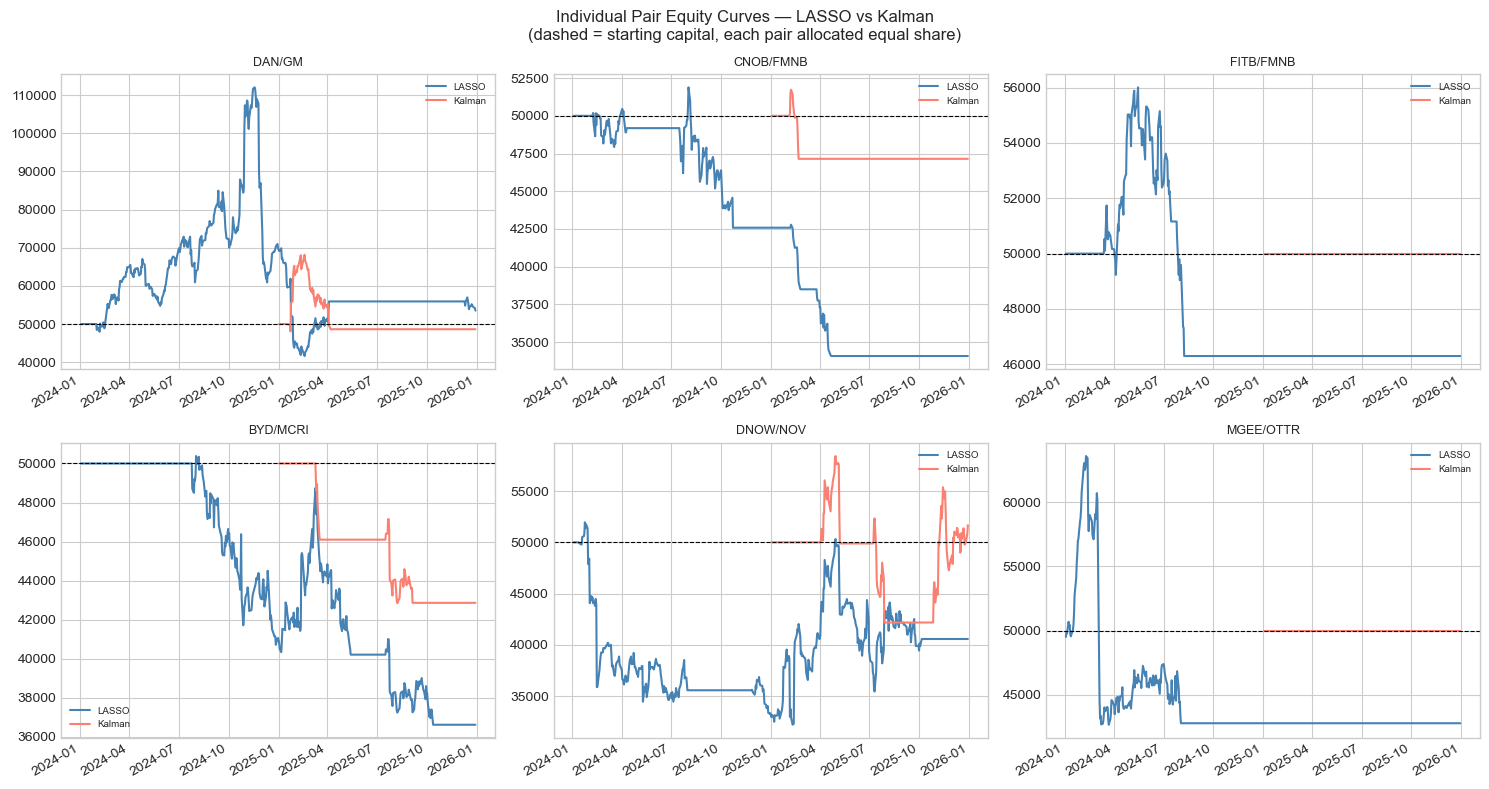

In [17]:
# Replicate the paper's 'each_pair_assets' figure
if lasso_returns or kalman_returns:
    show_n  = min(6, max(len(lasso_returns), len(kalman_returns)))
    n_cols  = 3
    n_rows  = (show_n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    # Flatten safely regardless of whether subplots returns a scalar, 1D, or 2D array
    axes = np.array(axes).reshape(-1)

    for i in range(show_n):
        ax = axes[i]
        if i < len(lasso_returns):
            eq = (1 + lasso_returns[i]).cumprod() * (INITIAL_CAPITAL / MAX_PAIRS)
            eq.plot(ax=ax, color='steelblue', lw=1.5, label='LASSO')
        if i < len(kalman_returns):
            eq2 = (1 + kalman_returns[i]).cumprod() * (INITIAL_CAPITAL / MAX_PAIRS)
            eq2.plot(ax=ax, color='salmon', lw=1.5, label='Kalman')
        name = lasso_returns[i].name if i < len(lasso_returns) else kalman_returns[i].name
        ax.set_title(name, fontsize=9)
        ax.axhline(INITIAL_CAPITAL / MAX_PAIRS, color='black', lw=0.8, linestyle='--')
        ax.legend(fontsize=7)

    for j in range(show_n, len(list(axes))):
        axes[j].set_visible(False)

    plt.suptitle('Individual Pair Equity Curves — LASSO vs Kalman\n'
                 '(dashed = starting capital, each pair allocated equal share)',
                 fontsize=12)
    plt.tight_layout(); plt.show()

> 💬 **What this does:** a grid showing how each individual pair performed over the test period. The dashed line is the starting capital for that pair. Some pairs will be profitable, some won't — this is expected and normal. The power of the strategy is that by combining many uncorrelated pairs, the wins and losses average out into a smoother overall result. This chart shows which pairs drove the performance and which were drag.

## 12. Performance Comparison Table

In [18]:
def compute_metrics(returns: pd.Series, label: str, spy_returns: pd.Series = None, rf: float = 0.05) -> dict:
    r = returns.squeeze().dropna()
    if r.empty:
        return {}
    daily_rf  = rf / 252
    excess    = r - daily_rf
    ann_ret   = float(r.mean() * 252)
    ann_vol   = float(r.std()  * np.sqrt(252))
    sharpe    = float(excess.mean() / r.std() * np.sqrt(252)) if r.std() > 0 else 0
    equity    = (1 + r).cumprod()
    dd        = equity / equity.cummax() - 1
    max_dd    = float(dd.min())
    # Sortino (downside std only)
    down      = r[r < daily_rf] - daily_rf
    down_std  = float(down.std() * np.sqrt(252)) if len(down) > 1 else np.nan
    sortino   = float(excess.mean() * 252 / down_std) if down_std and down_std > 0 else np.nan
    # Beta vs SPY
    if spy_returns is not None and not spy_returns.empty:
        common2 = r.index.intersection(spy_returns.index)
        if len(common2) > 10:
            cov  = np.cov(r.loc[common2].values, spy_returns.loc[common2].values)
            beta = float(cov[0, 1] / cov[1, 1]) if cov[1, 1] > 0 else 0
            alpha = ann_ret - beta * float(spy_returns.mean() * 252)
        else:
            beta, alpha = 0.0, ann_ret
    else:
        beta, alpha = 0.0, ann_ret

    return {
        'Strategy':         label,
        'Total Return':     f'{float(equity.iloc[-1]-1):+.2%}',
        'Annual Return':    f'{ann_ret:+.2%}',
        'Annual Vol':       f'{ann_vol:.4f}',
        'Sharpe Ratio':     f'{sharpe:.4f}',
        'Sortino Ratio':    f'{sortino:.4f}' if not np.isnan(sortino) else 'N/A',
        'Max Drawdown':     f'{max_dd:.4%}',
        'Alpha':            f'{alpha:.4%}',
        'Beta':             f'{beta:.4f}',
    }

rows = []
if not pl.empty:  rows.append(compute_metrics(pl,  'Linear Regression (LASSO)', spy_returns=spy))
if not pk.empty:  rows.append(compute_metrics(pk,  'Kalman Filter',             spy_returns=spy))
rows.append(compute_metrics(spy, 'SPY Buy & Hold'))

results_table = pd.DataFrame(rows).set_index('Strategy')
print('── Performance Metrics ──  (replicates paper Table 1)\n')
print(results_table.to_string())

── Performance Metrics ──  (replicates paper Table 1)

                          Total Return Annual Return Annual Vol Sharpe Ratio Sortino Ratio Max Drawdown     Alpha     Beta
Strategy                                                                                                                  
Linear Regression (LASSO)       -0.15%        -0.09%     0.0348      -1.4619       -1.9955     -2.9790%  -0.1646%   0.0038
Kalman Filter                   -3.95%        -3.99%     0.0411      -2.1861       -3.3717     -8.3548%  -3.3123%  -0.0355
SPY Buy & Hold                 +18.60%       +19.14%     0.1951       0.7249        0.9242    -18.7552%  19.1424%   0.0000


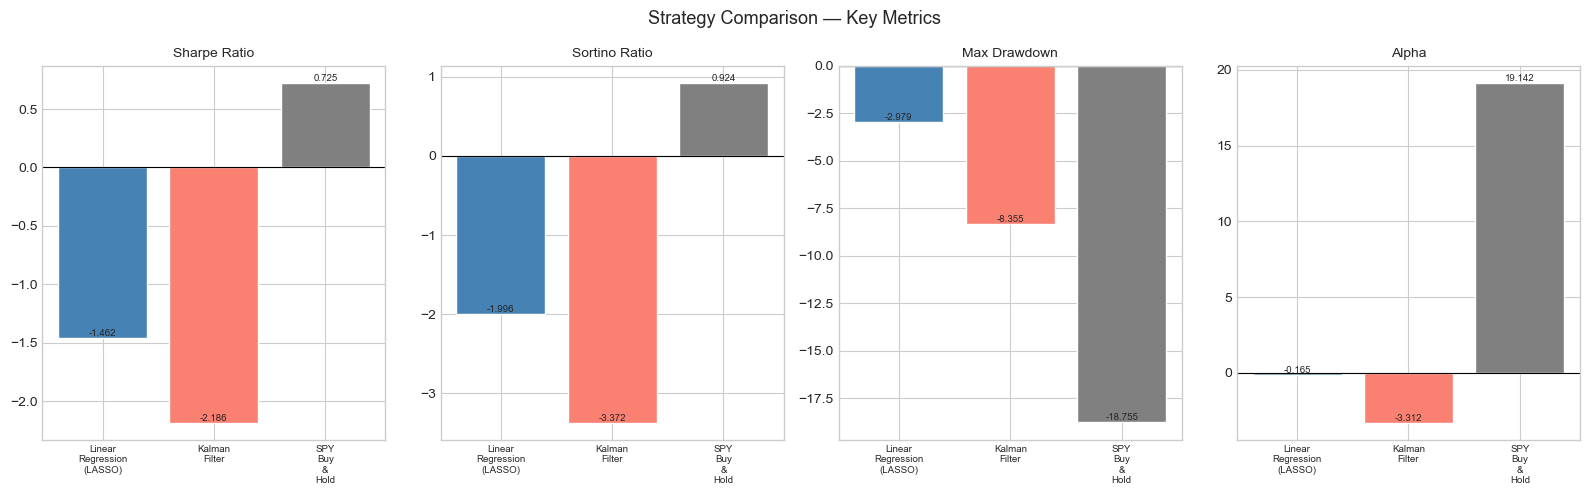

In [19]:
# Visual metrics comparison (bar charts)
if len(rows) >= 2:
    metrics_to_plot = ['Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Alpha']
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    colours = ['steelblue', 'salmon', 'grey']
    strategies = results_table.index.tolist()

    for ax, metric in zip(axes, metrics_to_plot):
        vals = []
        for s in strategies:
            try:
                v = str(results_table.loc[s, metric])
                if v == 'N/A':
                    vals.append(np.nan)
                else:
                    cleaned = v.replace('%', '').replace('+', '')
                    vals.append(float(cleaned))
            except:
                vals.append(np.nan)
        bars = ax.bar(strategies, vals,
                      color=colours[:len(strategies)], edgecolor='white')
        ax.set_title(metric, fontsize=10)
        ax.set_xticklabels([s.replace(' ',  '\n') for s in strategies], fontsize=7)
        ax.axhline(0, color='black', lw=0.8)
        # Label bars
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.001,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle('Strategy Comparison — Key Metrics', fontsize=13)
    plt.tight_layout(); plt.show()

> 💬 **What this does:** Provides our conclusion:
>
> The conclusion: **This is not a viable strategy... yet**. Both strategies not only fail to outperform SPY, but result in a negative return. Further study and parameter tuning would need to be done in order to determine if using ML in this way could become a viable strategy, but for now, it is not.